# Task 2
## Customer Segmentation Analysis

### Libraries to be Imported

In [1]:
import contextlib
import sklearn.utils.fixes
sklearn.utils.fixes.threadpool_limits = lambda *args, **kwargs: contextlib.nullcontext()

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
#reading the csv data using pandas
df=pd.read_csv("E-Commerce.csv")
df.head()

,CustomerID,Gender,InvoiceDate,InvoiceNumber,ProductID,Quantity,Price,Total,OrderStatus,Country,TrafficSource,SessionDuration,DeviceCategory,Device,OS,DeliveryRating,ProductRating,Sales
0,9691,Female,1/01/2019,26088332,32,3,91.37,274.11,Completed,India,Social Media,6.54,Computer,Laptop,Windows,2,5,274.11
1,8327,Female,1/01/2019,95183269,34,1,48.24,48.24,In Process,India,Social Media,5.01,Computer,Desktop,Windows,0,0,0.00
2,6801,Male,1/01/2019,44769684,64,2,35.23,70.46,Completed,United States,Paid Advertisment,0.10,Computer,Desktop,Windows,1,2,70.46
3,4406,Male,1/02/2019,12422351,41,2,32.33,64.66,Completed,Philippines,Social Media,1.95,Mobile,Tablet,Windows,4,4,64.66
4,1966,Male,1/03/2019,84352310,20,1,81.89,81.89,Completed,Brazil,Organic Search,9.15,Computer,Laptop,Windows,5,3,81.89


In [4]:
#used to collect details about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3599 entries, 0 to 3598
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       3599 non-null   int64  
 1   Gender           3599 non-null   object 
 2   InvoiceDate      3599 non-null   object 
 3   InvoiceNumber    3599 non-null   int64  
 4   ProductID        3599 non-null   int64  
 5   Quantity         3599 non-null   int64  
 6   Price            3599 non-null   float64
 7   Total            3599 non-null   float64
 8   OrderStatus      3599 non-null   object 
 9   Country          3599 non-null   object 
 10  TrafficSource    3599 non-null   object 
 11  SessionDuration  3599 non-null   float64
 12  DeviceCategory   3599 non-null   object 
 13  Device           3599 non-null   object 
 14  OS               3599 non-null   object 
 15  DeliveryRating   3599 non-null   int64  
 16  ProductRating    3599 non-null   int64  
 17  Sales         

In [5]:
df.describe()

,CustomerID,InvoiceNumber,ProductID,Quantity,Price,Total,SessionDuration,DeliveryRating,ProductRating,Sales
count,3599.000000,3.599000e+03,3599.000000,3599.000000,3599.000000,3599.000000,3599.000000,3599.000000,3599.000000,3599.000000
mean,5526.962767,5.582117e+07,50.864962,2.000556,48.714571,97.394143,4.992101,2.641011,2.653515,61.185285
std,2586.425565,2.568169e+07,29.035862,0.813313,29.499165,74.421471,2.896605,2.181087,2.179732,75.880928
min,1111.000000,1.114055e+07,1.000000,1.000000,1.220000,1.220000,0.010000,0.000000,0.000000,0.000000
25%,3288.000000,3.355699e+07,26.000000,1.000000,26.030000,37.610000,2.490000,0.000000,0.000000,0.000000
50%,5546.000000,5.614293e+07,52.000000,2.000000,43.500000,81.460000,4.930000,3.000000,4.000000,31.260000
75%,7777.000000,7.810160e+07,76.000000,3.000000,74.550000,147.060000,7.515000,5.000000,5.000000,98.040000
max,9998.000000,9.996354e+07,100.000000,3.000000,99.720000,299.160000,10.000000,5.000000,5.000000,299.160000


In [6]:
#checking the missing values 
df.isnull().sum()

CustomerID         0
Gender             0
InvoiceDate        0
InvoiceNumber      0
ProductID          0
Quantity           0
Price              0
Total              0
OrderStatus        0
Country            0
TrafficSource      0
SessionDuration    0
DeviceCategory     0
Device             0
OS                 0
DeliveryRating     0
ProductRating      0
Sales              0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
# fixing date format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%Y')

In [9]:
df['InvoiceDate']

0      2019-01-01
1      2019-01-01
2      2019-01-01
3      2019-01-02
4      2019-01-03
          ...    
3594   2023-12-29
3595   2023-12-30
3596   2023-12-31
3597   2023-12-31
3598   2023-12-31
Name: InvoiceDate, Length: 3599, dtype: datetime64[ns]

In [10]:
df['OrderStatus'].value_counts()

OrderStatus
Completed     2245
In Process     665
Cancelled      457
Returned       232
Name: count, dtype: int64

In [11]:
#keeping only completed orders
df_clean = df[df['OrderStatus'] == 'Completed'].copy()
df_clean.head()

,CustomerID,Gender,InvoiceDate,InvoiceNumber,ProductID,Quantity,Price,Total,OrderStatus,Country,TrafficSource,SessionDuration,DeviceCategory,Device,OS,DeliveryRating,ProductRating,Sales
0,9691,Female,2019-01-01,26088332,32,3,91.37,274.11,Completed,India,Social Media,6.54,Computer,Laptop,Windows,2,5,274.11
2,6801,Male,2019-01-01,44769684,64,2,35.23,70.46,Completed,United States,Paid Advertisment,0.10,Computer,Desktop,Windows,1,2,70.46
3,4406,Male,2019-01-02,12422351,41,2,32.33,64.66,Completed,Philippines,Social Media,1.95,Mobile,Tablet,Windows,4,4,64.66
4,1966,Male,2019-01-03,84352310,20,1,81.89,81.89,Completed,Brazil,Organic Search,9.15,Computer,Laptop,Windows,5,3,81.89
5,6148,Male,2019-01-03,53293645,10,3,19.34,58.02,Completed,Egypt,Organic Search,7.89,Computer,Desktop,Windows,4,5,58.02


In [12]:
#aggregating
customer_stats = df_clean.groupby('CustomerID').agg(
    Frequency=('InvoiceNumber', 'count'),
    Monetary=('Total', 'sum'),
    AvgOrderValue=('Total', 'mean'),
    LastPurchaseDate=('InvoiceDate', 'max')
).reset_index()

customer_stats.head()

,CustomerID,Frequency,Monetary,AvgOrderValue,LastPurchaseDate
0,1111,1,105.56,105.56,2022-09-15
1,1119,1,218.79,218.79,2023-05-28
2,1122,1,78.78,78.78,2023-10-08
3,1123,1,97.29,97.29,2019-11-23
4,1129,1,39.60,39.60,2020-12-11


In [13]:
customer_stats.describe()

,CustomerID,Frequency,Monetary,AvgOrderValue,LastPurchaseDate
count,1968.000000,1968.000000,1968.000000,1968.000000,1968
mean,5523.605691,1.140752,111.893211,97.530538,2021-08-18 08:42:26.341463296
min,1111.000000,1.000000,1.220000,1.220000,2019-01-01 00:00:00
25%,3263.500000,1.000000,40.300000,39.240000,2020-05-10 18:00:00
50%,5521.000000,1.000000,91.280000,82.960000,2021-09-18 12:00:00
75%,7779.250000,1.000000,163.780000,144.480000,2022-11-25 00:00:00
max,9998.000000,3.000000,597.900000,299.160000,2023-12-31 00:00:00
std,2589.614132,0.375949,90.247335,72.308300,NaN


In [14]:
customer_stats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1968 entries, 0 to 1967
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CustomerID        1968 non-null   int64         
 1   Frequency         1968 non-null   int64         
 2   Monetary          1968 non-null   float64       
 3   AvgOrderValue     1968 non-null   float64       
 4   LastPurchaseDate  1968 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(2)
memory usage: 77.0 KB


In [15]:
#RFM table building
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
customer_stats['Recency'] = (snapshot_date - customer_stats['LastPurchaseDate']).dt.days

rfm = customer_stats[['CustomerID', 'Recency', 'Frequency', 'Monetary']].copy()
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,1111,473,1,105.56
1,1119,218,1,218.79
2,1122,85,1,78.78
3,1123,1500,1,97.29
4,1129,1116,1,39.60


In [16]:
#Standardizing/Normalizing
features = ['Recency', 'Frequency', 'Monetary']
X = rfm[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

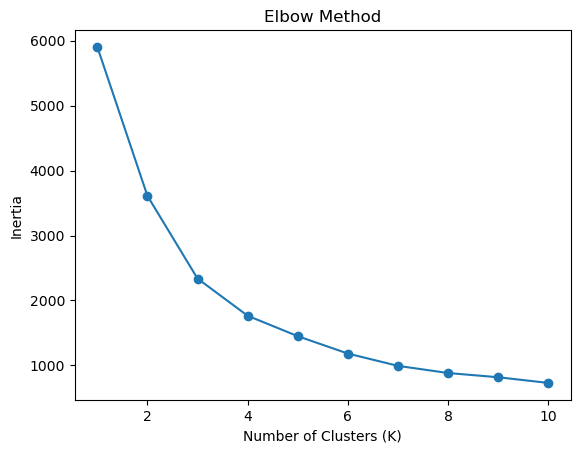

In [17]:
#Elbow method
inertia = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
plt.plot(list(K_range), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [18]:
#fitting KMeans
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,1111,473,1,105.56,1
1,1119,218,1,218.79,0
2,1122,85,1,78.78,1
3,1123,1500,1,97.29,2
4,1129,1116,1,39.60,2


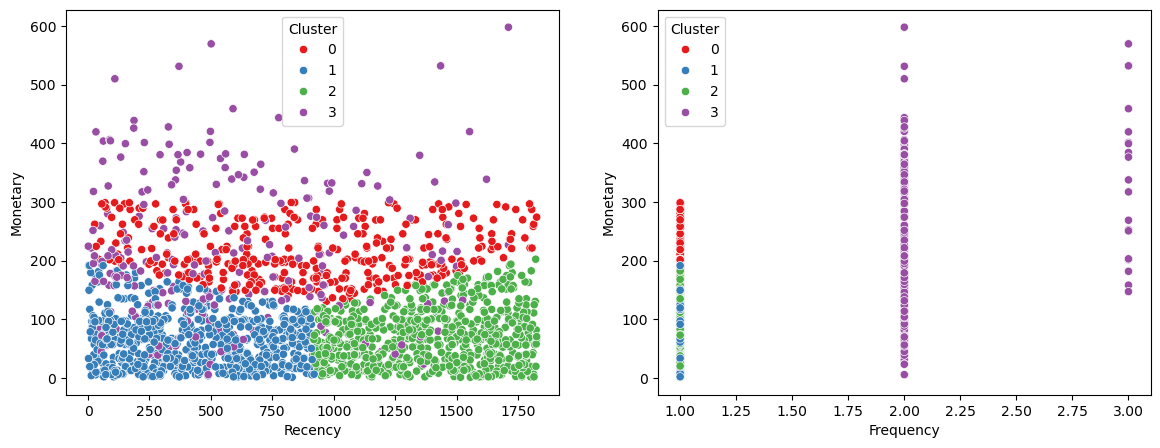

In [19]:
#plotting scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='Set1', ax=axes[0])
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='Set1', ax=axes[1])
plt.show()

In [20]:
#cluster profiling
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
cluster_profile['CustomerCount'] = rfm['Cluster'].value_counts()
cluster_profile

,Recency,Frequency,Monetary,CustomerCount
Cluster,,,,
0,901.540230,1.000000,214.717069,348
1,438.985380,1.000000,64.050775,684
2,1391.508824,1.001471,69.655000,680
3,559.945312,2.078125,212.141289,256


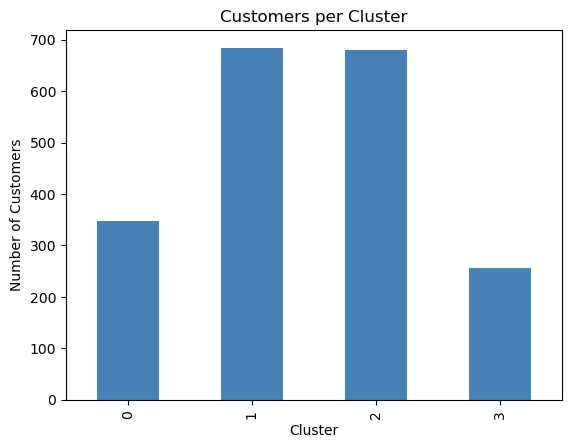

In [21]:
#Bar chart for number of customers per cluster
rfm['Cluster'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Customers per Cluster')
plt.show()

### Insights
Looking over the cluster profiling, 
<br>
<br>Cluster 3 are the only repeat customers who are just 256. we have to keep those customers happy by providing extra benifits.
<br>
<br>All other customers are once customers. We have to get them back. For getting them back we can keep offers, winner games, discounts etc.
<br>
<br>Looking at Cluster 1 and 2, there are more numbers of customers but their purchase is of less amount. We can increase there purchase by keeping rewards or buy one get one free offer so that their purchase amount will increase. 
<br>
<br>By looking at Cluster 0 we can see that these customers are big deal customers but those were one time customer they did not return back. We can contact them or send them reward related posts to get them back.
<br>
<br>These were the insights look over.